<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_AnalisisBentuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS - Region Properties, Boundary Representation & Shape Descriptors
### Dataset: 3 Kelas Objek CITRA ASLI (Apel, Pisang, Jeruk) — 8 Sampel per Kelas

**Instruksi Penggunaan:**
1. Jalankan sel pertama untuk menginstall/import library.
2. Jalankan **Bagian 1** untuk mengupload foto dari perangkat Anda.
3. Upload **minimal 3 foto per kelas** (Apel, Pisang, Jeruk) saat diminta — sistem akan augmentasi otomatis hingga 8 sampel.
4. Lanjutkan menjalankan bagian 2–7 seperti biasa.

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import files
from PIL import Image
import io, os
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport.')

Library berhasil diimport.


## BAGIAN 1 — Upload Citra Asli dari Perangkat

Upload foto dari kamera/galeri perangkat Anda:
- **Kelas 0 — Apel**: minimal 3 foto, format JPG/PNG
- **Kelas 1 — Pisang**: minimal 3 foto, format JPG/PNG  
- **Kelas 2 — Jeruk**: minimal 3 foto, format JPG/PNG

> Tips: Foto dengan latar belakang polos (putih/hitam) akan menghasilkan segmentasi lebih akurat.


📷  Upload foto APEL (minimal 3 file, format JPG/PNG):


Saving apel1.png to apel1.png
  ✔ apel1.png berhasil diproses.
  → 8 sampel Apel siap (termasuk augmentasi).

📷  Upload foto PISANG (minimal 3 file, format JPG/PNG):


Saving pisang1.jpeg to pisang1.jpeg
  ✔ pisang1.jpeg berhasil diproses.
  → 8 sampel Pisang siap (termasuk augmentasi).

📷  Upload foto JERUK (minimal 3 file, format JPG/PNG):


Saving jeruk1.jpeg to jeruk1.jpeg
  ✔ jeruk1.jpeg berhasil diproses.
  → 8 sampel Jeruk siap (termasuk augmentasi).


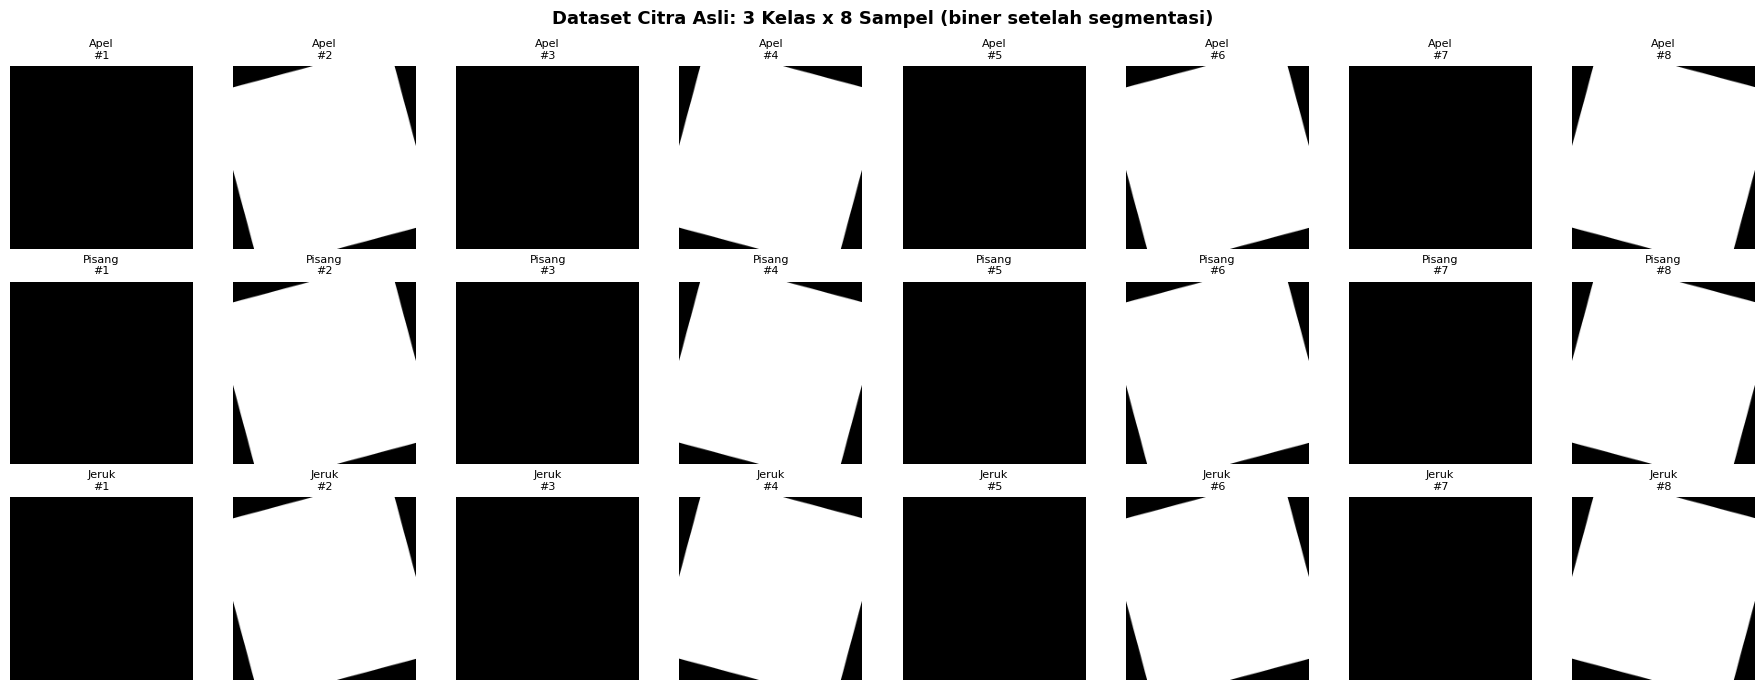

Total sampel: 24 (8 per kelas)


In [2]:
# ============================================================
# BAGIAN 1 - UPLOAD CITRA ASLI DARI PERANGKAT
# ============================================================

IMG_SIZE = 200  # Ukuran standar untuk semua gambar

class_names = ['Apel', 'Pisang', 'Jeruk']
N_SAMPLES   = 8   # target sampel per kelas


def load_and_preprocess(file_bytes, target_size=IMG_SIZE):
    """Baca bytes gambar → grayscale biner (200x200)."""
    img_pil  = Image.open(io.BytesIO(file_bytes)).convert('RGB')
    img_rgb  = np.array(img_pil)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    img_res  = cv2.resize(img_gray, (target_size, target_size))

    # --- Segmentasi otomatis: Otsu thresholding ---
    # Blur dulu untuk kurangi noise
    blur = cv2.GaussianBlur(img_res, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Pastikan objek = putih (255). Jika latar terang, inverskan.
    white_px = np.sum(thresh == 255)
    black_px = np.sum(thresh == 0)
    if white_px < black_px:
        thresh = cv2.bitwise_not(thresh)

    # Morphological closing untuk tutup lubang kecil
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,  kernel)

    # Ambil kontur terbesar saja
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        mask = np.zeros_like(thresh)
        biggest = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [biggest], -1, 255, -1)
        thresh = mask

    return img_res, thresh


def augment_to_n(images, n=8):
    """Augmentasi gambar (flip, rotasi kecil) sampai sejumlah n."""
    augmented = list(images)
    idx = 0
    while len(augmented) < n:
        src = images[idx % len(images)]
        choice = len(augmented) % 4
        h, w = src.shape
        center = (w // 2, h // 2)
        if choice == 0:
            aug = cv2.flip(src, 1)                              # flip horizontal
        elif choice == 1:
            M = cv2.getRotationMatrix2D(center, 15, 1.0)
            aug = cv2.warpAffine(src, M, (w, h))               # rotasi +15°
        elif choice == 2:
            aug = cv2.flip(src, 0)                              # flip vertikal
        else:
            M = cv2.getRotationMatrix2D(center, -15, 1.0)
            aug = cv2.warpAffine(src, M, (w, h))               # rotasi -15°
        augmented.append(aug)
        idx += 1
    return augmented[:n]


dataset      = []   # citra biner (200x200) untuk ekstraksi fitur
dataset_gray = []   # citra grayscale asli untuk visualisasi
labels       = []

for cls_idx, cls_name in enumerate(class_names):
    print(f'\n📷  Upload foto {cls_name.upper()} (minimal 3 file, format JPG/PNG):')
    uploaded = files.upload()   # dialog upload muncul di sini

    bin_imgs  = []
    gray_imgs = []
    for fname, fbytes in uploaded.items():
        gray, binary = load_and_preprocess(fbytes)
        bin_imgs.append(binary)
        gray_imgs.append(gray)
        print(f'  ✔ {fname} berhasil diproses.')

    # Augmentasi ke N_SAMPLES
    bin_imgs  = augment_to_n(bin_imgs,  n=N_SAMPLES)
    gray_imgs = augment_to_n(gray_imgs, n=N_SAMPLES)

    dataset      += bin_imgs
    dataset_gray += gray_imgs
    labels       += [cls_idx] * N_SAMPLES
    print(f'  → {N_SAMPLES} sampel {cls_name} siap (termasuk augmentasi).')


# Visualisasi sampel dataset
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('Dataset Citra Asli: 3 Kelas x 8 Sampel (biner setelah segmentasi)', fontsize=13, fontweight='bold')

for cls in range(3):
    for s in range(8):
        idx = cls * 8 + s
        axes[cls, s].imshow(dataset[idx], cmap='gray')
        axes[cls, s].set_title(f'{class_names[cls]}\n#{s+1}', fontsize=8)
        axes[cls, s].axis('off')

plt.tight_layout()
plt.show()
print(f'Total sampel: {len(dataset)} ({len(dataset)//3} per kelas)')

## BAGIAN 1b — Pratinjau Proses Segmentasi (Opsional)
Sel ini menampilkan perbandingan citra asli vs hasil segmentasi untuk memastikan kualitas mask.

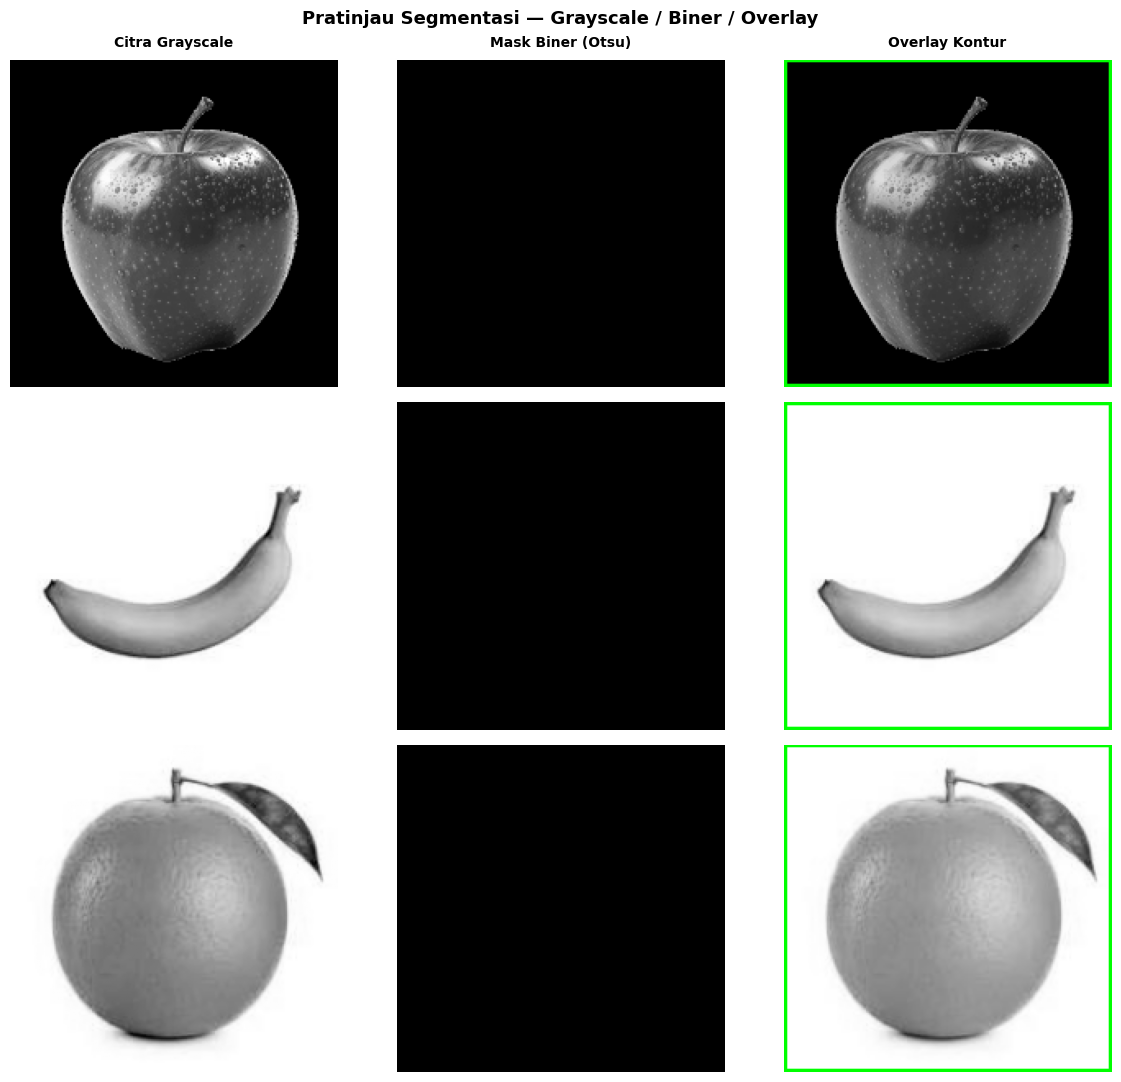

In [3]:
# ============================================================
# BAGIAN 1b - PRATINJAU SEGMENTASI (1 sampel per kelas)
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(12, 11))
fig.suptitle('Pratinjau Segmentasi — Grayscale / Biner / Overlay', fontsize=13, fontweight='bold')

col_titles = ['Citra Grayscale', 'Mask Biner (Otsu)', 'Overlay Kontur']
for c, t in enumerate(col_titles):
    axes[0, c].set_title(t, fontsize=10, fontweight='bold', pad=10)

for cls in range(3):
    idx   = cls * 8
    gray  = dataset_gray[idx]
    biner = dataset[idx]

    # Overlay: gambar grayscale + kontur hijau
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    contours, _ = cv2.findContours(biner, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

    axes[cls, 0].imshow(gray,  cmap='gray')
    axes[cls, 0].set_ylabel(class_names[cls], fontsize=11, fontweight='bold')
    axes[cls, 0].axis('off')

    axes[cls, 1].imshow(biner, cmap='gray')
    axes[cls, 1].axis('off')

    axes[cls, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[cls, 2].axis('off')

plt.tight_layout()
plt.show()

## BAGIAN 2 — Ekstraksi Region Properties

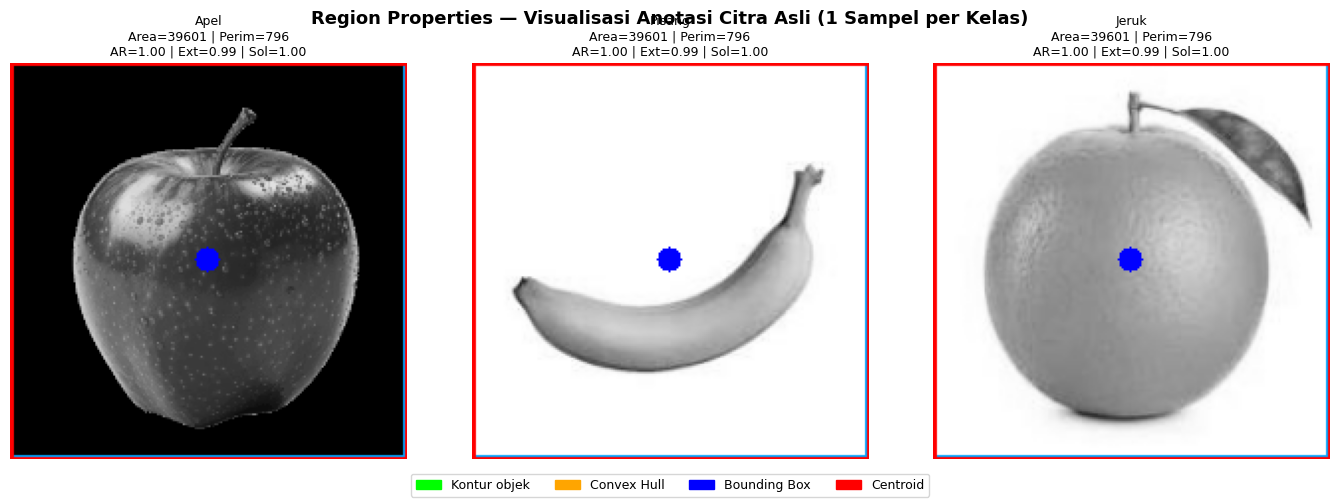


TABEL REGION PROPERTIES (3 sampel pertama tiap kelas):
 Class  Sample    Area  Perimeter  Aspect_Ratio  Extent  Solidity  Compactness
  Apel       1 39601.0      796.0           1.0   0.990     1.000        1.273
  Apel       2 35778.5      742.7           1.0   0.894     0.996        1.227
  Apel       3 39601.0      796.0           1.0   0.990     1.000        1.273
Pisang       1 39601.0      796.0           1.0   0.990     1.000        1.273
Pisang       2 35778.5      742.7           1.0   0.894     0.996        1.227
Pisang       3 39601.0      796.0           1.0   0.990     1.000        1.273
 Jeruk       1 39601.0      796.0           1.0   0.990     1.000        1.273
 Jeruk       2 35778.5      742.7           1.0   0.894     0.996        1.227
 Jeruk       3 39601.0      796.0           1.0   0.990     1.000        1.273


In [4]:
# ============================================================
# BAGIAN 2 - EKSTRAKSI REGION PROPERTIES
# Luas, perimeter, centroid, bounding box,
# convex hull, aspect ratio, extent, solidity
# ============================================================

def extract_region_properties(img):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)

    # --- Luas & Perimeter ---
    area      = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    # --- Centroid (dari moments) ---
    M  = cv2.moments(contour)
    cx = int(M['m10'] / M['m00']) if M['m00'] != 0 else 0
    cy = int(M['m01'] / M['m00']) if M['m00'] != 0 else 0

    # --- Bounding Box ---
    x, y, w, h = cv2.boundingRect(contour)

    # --- Convex Hull ---
    hull      = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)

    # --- Shape Descriptors ---
    aspect_ratio  = float(w) / h if h > 0 else 0
    extent        = area / (w * h) if (w * h) > 0 else 0
    solidity      = area / hull_area if hull_area > 0 else 0
    compactness   = (perimeter ** 2) / (4 * np.pi * area) if area > 0 else 0
    equi_diameter = np.sqrt(4 * area / np.pi)

    return {
        'area': area, 'perimeter': perimeter,
        'centroid': (cx, cy),
        'bbox': (x, y, w, h),
        'hull_area': hull_area,
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'solidity': solidity,
        'compactness': compactness,
        'equi_diameter': equi_diameter,
        'contour': contour,
        'hull': hull,
        'moments': M
    }

# Ekstraksi untuk semua sampel
region_props = [extract_region_properties(img) for img in dataset]

# Visualisasi anotasi (1 contoh per kelas)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Region Properties — Visualisasi Anotasi Citra Asli (1 Sampel per Kelas)', fontsize=13, fontweight='bold')

for cls in range(3):
    idx  = cls * 8
    prop = region_props[idx]
    # Gunakan grayscale asli sebagai latar (lebih informatif)
    vis  = cv2.cvtColor(dataset_gray[idx], cv2.COLOR_GRAY2BGR)

    cv2.drawContours(vis, [prop['contour']], -1, (0,255,0), 2)
    cv2.drawContours(vis, [prop['hull']],    -1, (255,165,0), 2)
    x,y,w,h = prop['bbox']
    cv2.rectangle(vis, (x,y), (x+w,y+h), (0,0,255), 2)
    cxp, cyp = prop['centroid']
    cv2.circle(vis, (cxp,cyp), 6, (255,0,0), -1)

    axes[cls].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[cls].set_title(
        f"{class_names[cls]}\n"
        f"Area={prop['area']:.0f} | Perim={prop['perimeter']:.0f}\n"
        f"AR={prop['aspect_ratio']:.2f} | Ext={prop['extent']:.2f} | Sol={prop['solidity']:.2f}",
        fontsize=9
    )
    axes[cls].axis('off')

# Legenda warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#00FF00', label='Kontur objek'),
    Patch(color='#FFA500', label='Convex Hull'),
    Patch(color='#0000FF', label='Bounding Box'),
    Patch(color='#FF0000', label='Centroid'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# Tabel ringkasan
rows = []
for i, (prop, lbl) in enumerate(zip(region_props, labels)):
    rows.append({
        'Class': class_names[lbl], 'Sample': (i % 8) + 1,
        'Area': round(prop['area'],1), 'Perimeter': round(prop['perimeter'],1),
        'Aspect_Ratio': round(prop['aspect_ratio'],3),
        'Extent': round(prop['extent'],3), 'Solidity': round(prop['solidity'],3),
        'Compactness': round(prop['compactness'],3)
    })

df_region = pd.DataFrame(rows)
print('\nTABEL REGION PROPERTIES (3 sampel pertama tiap kelas):')
print(df_region.groupby('Class').head(3).to_string(index=False))

## BAGIAN 3 — Implementasi Moments

SPATIAL MOMENTS (1 sampel per kelas):
Class                 m00            m10            m01
-------------------------------------------------------
Apel              39601.0      3940299.5      3940299.5
Pisang            39601.0      3940299.5      3940299.5
Jeruk             39601.0      3940299.5      3940299.5

CENTRAL MOMENTS (1 sampel per kelas):
Class                mu20         mu02         mu11
--------------------------------------------------
Apel          130686600.1  130686600.1          0.0
Pisang        130686600.1  130686600.1          0.0
Jeruk         130686600.1  130686600.1          0.0

HU MOMENTS LOG SCALE (1 sampel per kelas):
Class             Hu1      Hu2      Hu3      Hu4      Hu5      Hu6      Hu7
----------------------------------------------------------------------
Apel            0.778    0.000    0.000    0.000    0.000    0.000    0.000
Pisang          0.778    0.000    0.000    0.000    0.000    0.000    0.000
Jeruk           0.778    0.000    0.000  

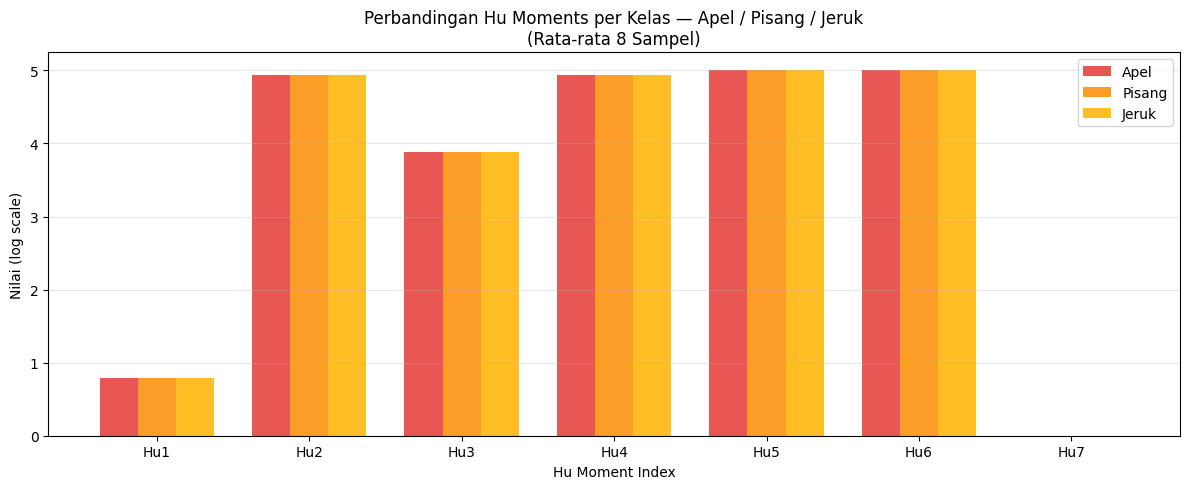

In [5]:
# ============================================================
# BAGIAN 3 - IMPLEMENTASI MOMENTS
# Spatial moments, central moments, Hu moments
# ============================================================

def extract_moments(img):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)
    M = cv2.moments(contour)

    # --- Spatial Moments ---
    spatial = {'m00': M['m00'], 'm10': M['m10'], 'm01': M['m01'],
               'm20': M['m20'], 'm02': M['m02'], 'm11': M['m11']}

    # --- Central Moments ---
    central = {'mu20': M['mu20'], 'mu02': M['mu02'], 'mu11': M['mu11'],
               'mu30': M['mu30'], 'mu03': M['mu03']}

    # --- Hu Moments (7 invariant moments) ---
    hu = cv2.HuMoments(M).flatten()
    # Log transform agar lebih mudah dibandingkan
    hu_log = np.array([-np.sign(h) * np.log10(abs(h) + 1e-10) for h in hu])

    return {'spatial': spatial, 'central': central,
            'hu': hu, 'hu_log': hu_log, 'raw': M}

all_moments = [extract_moments(img) for img in dataset]

# Tampilkan moments satu sampel per kelas
print('SPATIAL MOMENTS (1 sampel per kelas):')
print(f"{'Class':<12} {'m00':>12} {'m10':>14} {'m01':>14}")
print('-' * 55)
for cls in range(3):
    m = all_moments[cls * 8]['spatial']
    print(f"{class_names[cls]:<12} {m['m00']:>12.1f} {m['m10']:>14.1f} {m['m01']:>14.1f}")

print('\nCENTRAL MOMENTS (1 sampel per kelas):')
print(f"{'Class':<12} {'mu20':>12} {'mu02':>12} {'mu11':>12}")
print('-' * 50)
for cls in range(3):
    m = all_moments[cls * 8]['central']
    print(f"{class_names[cls]:<12} {m['mu20']:>12.1f} {m['mu02']:>12.1f} {m['mu11']:>12.1f}")

print('\nHU MOMENTS LOG SCALE (1 sampel per kelas):')
header = f"{'Class':<12}" + ''.join([f" {'Hu'+str(i+1):>8}" for i in range(7)])
print(header)
print('-' * 70)
for cls in range(3):
    hu  = all_moments[cls * 8]['hu_log']
    row = f"{class_names[cls]:<12}" + ''.join([f" {v:>8.3f}" for v in hu])
    print(row)

# Visualisasi Hu Moments per kelas
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(7)
width = 0.25
colors = ['#E53935', '#FB8C00', '#FFB300']   # merah=Apel, oranye=Pisang, kuning=Jeruk

for cls in range(3):
    avg_hu = np.mean([all_moments[cls*8+s]['hu_log'] for s in range(8)], axis=0)
    ax.bar(x + cls*width, avg_hu, width, label=class_names[cls], color=colors[cls], alpha=0.85)

ax.set_xlabel('Hu Moment Index')
ax.set_ylabel('Nilai (log scale)')
ax.set_title('Perbandingan Hu Moments per Kelas — Apel / Pisang / Jeruk\n(Rata-rata 8 Sampel)')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Hu{i+1}' for i in range(7)])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## BAGIAN 4 — Representasi Batas (Chain Code & Polygonal Approximation)

CHAIN CODE ANALYSIS — Citra Asli

Apel:
  Chain 8-arah : 796 kode | 10 pertama: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Chain 4-arah : 796 kode | 10 pertama: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Normalized   : 10 pertama: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Polygon pts  : 4 titik

Pisang:
  Chain 8-arah : 796 kode | 10 pertama: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Chain 4-arah : 796 kode | 10 pertama: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Normalized   : 10 pertama: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Polygon pts  : 4 titik

Jeruk:
  Chain 8-arah : 796 kode | 10 pertama: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Chain 4-arah : 796 kode | 10 pertama: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Normalized   : 10 pertama: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Polygon pts  : 4 titik


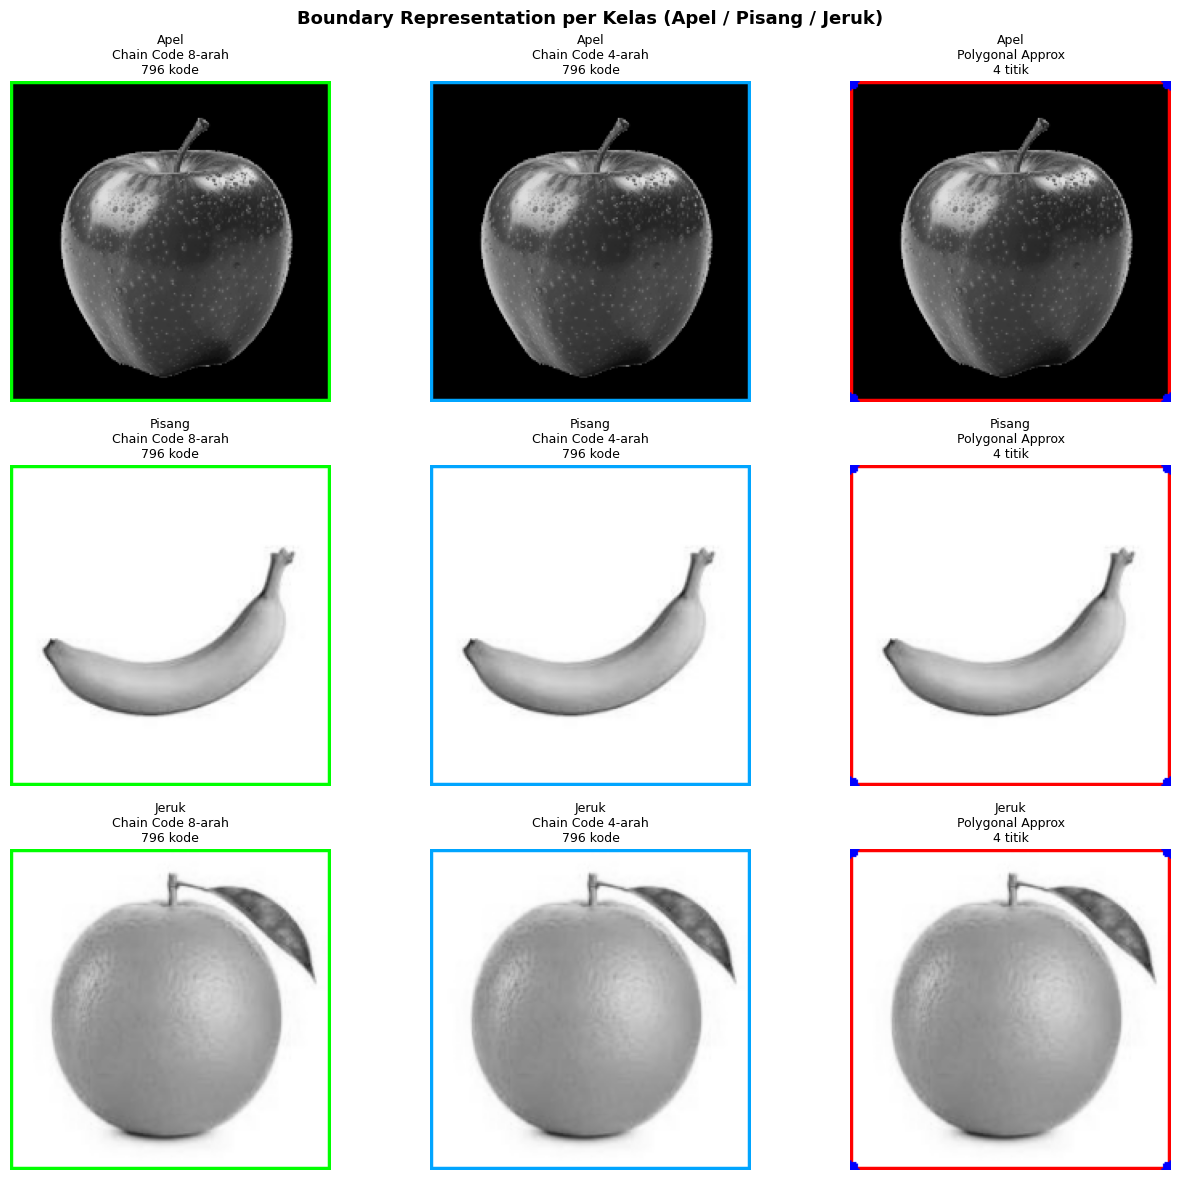

In [6]:
# ============================================================
# BAGIAN 4 - REPRESENTASI BATAS
# Chain codes 4-arah & 8-arah, normalisasi, polygonal approx
# ============================================================

def compute_chain_code(contour, mode=8):
    """Hitung chain code 4-arah atau 8-arah dari kontur."""
    if mode == 8:
        directions = [(1,0),(1,1),(0,1),(-1,1),(-1,0),(-1,-1),(0,-1),(1,-1)]
        dir_names  = ['E','SE','S','SW','W','NW','N','NE']
    else:  # 4-arah
        directions = [(1,0),(0,1),(-1,0),(0,-1)]
        dir_names  = ['E','S','W','N']

    # Sederhanakan kontur
    pts = []
    for i in range(len(contour)):
        p = contour[i][0]
        if i == 0 or not np.array_equal(p, contour[i-1][0]):
            pts.append(p)

    chain = []
    for i in range(len(pts)):
        cur = pts[i]
        nxt = pts[(i+1) % len(pts)]
        dx  = int(nxt[0]) - int(cur[0])
        dy  = int(nxt[1]) - int(cur[1])
        dx  = max(-1, min(1, dx))
        dy  = max(-1, min(1, dy))
        for code, (ddx, ddy) in enumerate(directions):
            if dx == ddx and dy == ddy:
                chain.append(code)
                break

    return chain, pts, dir_names


def normalize_chain_code(chain):
    """Normalisasi chain code ke rotasi minimum."""
    if not chain:
        return chain
    doubled = chain + chain
    n       = len(chain)
    min_rot = chain
    for i in range(n):
        candidate = doubled[i:i+n]
        if candidate < min_rot:
            min_rot = candidate
    return min_rot


def polygonal_approx(contour, epsilon_factor=0.02):
    """Douglas-Peucker polygonal approximation."""
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx  = cv2.approxPolyDP(contour, epsilon, True)
    return approx


# Analisis chain code satu sampel per kelas
print('CHAIN CODE ANALYSIS — Citra Asli')
print('=' * 60)

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.suptitle('Boundary Representation per Kelas (Apel / Pisang / Jeruk)', fontsize=13, fontweight='bold')

for cls in range(3):
    img     = dataset[cls * 8]
    gray_bg = dataset_gray[cls * 8]   # latar grayscale asli
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour = max(contours, key=cv2.contourArea)

    chain8, pts8, _ = compute_chain_code(contour, mode=8)
    chain4, pts4, _ = compute_chain_code(contour, mode=4)
    norm_chain      = normalize_chain_code(chain8)
    poly_approx_pts = polygonal_approx(contour)

    # Kolom 0: Chain code 8-arah
    vis8 = cv2.cvtColor(gray_bg.copy(), cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis8, [contour], -1, (0,255,0), 2)
    axes[cls,0].imshow(cv2.cvtColor(vis8, cv2.COLOR_BGR2RGB))
    axes[cls,0].set_title(f'{class_names[cls]}\nChain Code 8-arah\n{len(chain8)} kode', fontsize=9)
    axes[cls,0].axis('off')

    # Kolom 1: Chain code 4-arah
    vis4 = cv2.cvtColor(gray_bg.copy(), cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis4, [contour], -1, (255,165,0), 2)
    axes[cls,1].imshow(cv2.cvtColor(vis4, cv2.COLOR_BGR2RGB))
    axes[cls,1].set_title(f'{class_names[cls]}\nChain Code 4-arah\n{len(chain4)} kode', fontsize=9)
    axes[cls,1].axis('off')

    # Kolom 2: Polygonal Approximation
    vis_poly = cv2.cvtColor(gray_bg.copy(), cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis_poly, [poly_approx_pts], -1, (0,0,255), 2)
    for p in poly_approx_pts:
        cv2.circle(vis_poly, tuple(p[0]), 5, (255,0,0), -1)
    axes[cls,2].imshow(cv2.cvtColor(vis_poly, cv2.COLOR_BGR2RGB))
    axes[cls,2].set_title(f'{class_names[cls]}\nPolygonal Approx\n{len(poly_approx_pts)} titik', fontsize=9)
    axes[cls,2].axis('off')

    # Print info
    print(f'\n{class_names[cls]}:')
    print(f'  Chain 8-arah : {len(chain8)} kode | 10 pertama: {chain8[:10]}')
    print(f'  Chain 4-arah : {len(chain4)} kode | 10 pertama: {chain4[:10]}')
    print(f'  Normalized   : 10 pertama: {norm_chain[:10]}')
    print(f'  Polygon pts  : {len(poly_approx_pts)} titik')

plt.tight_layout()
plt.show()

## BAGIAN 5 — Fourier Descriptors

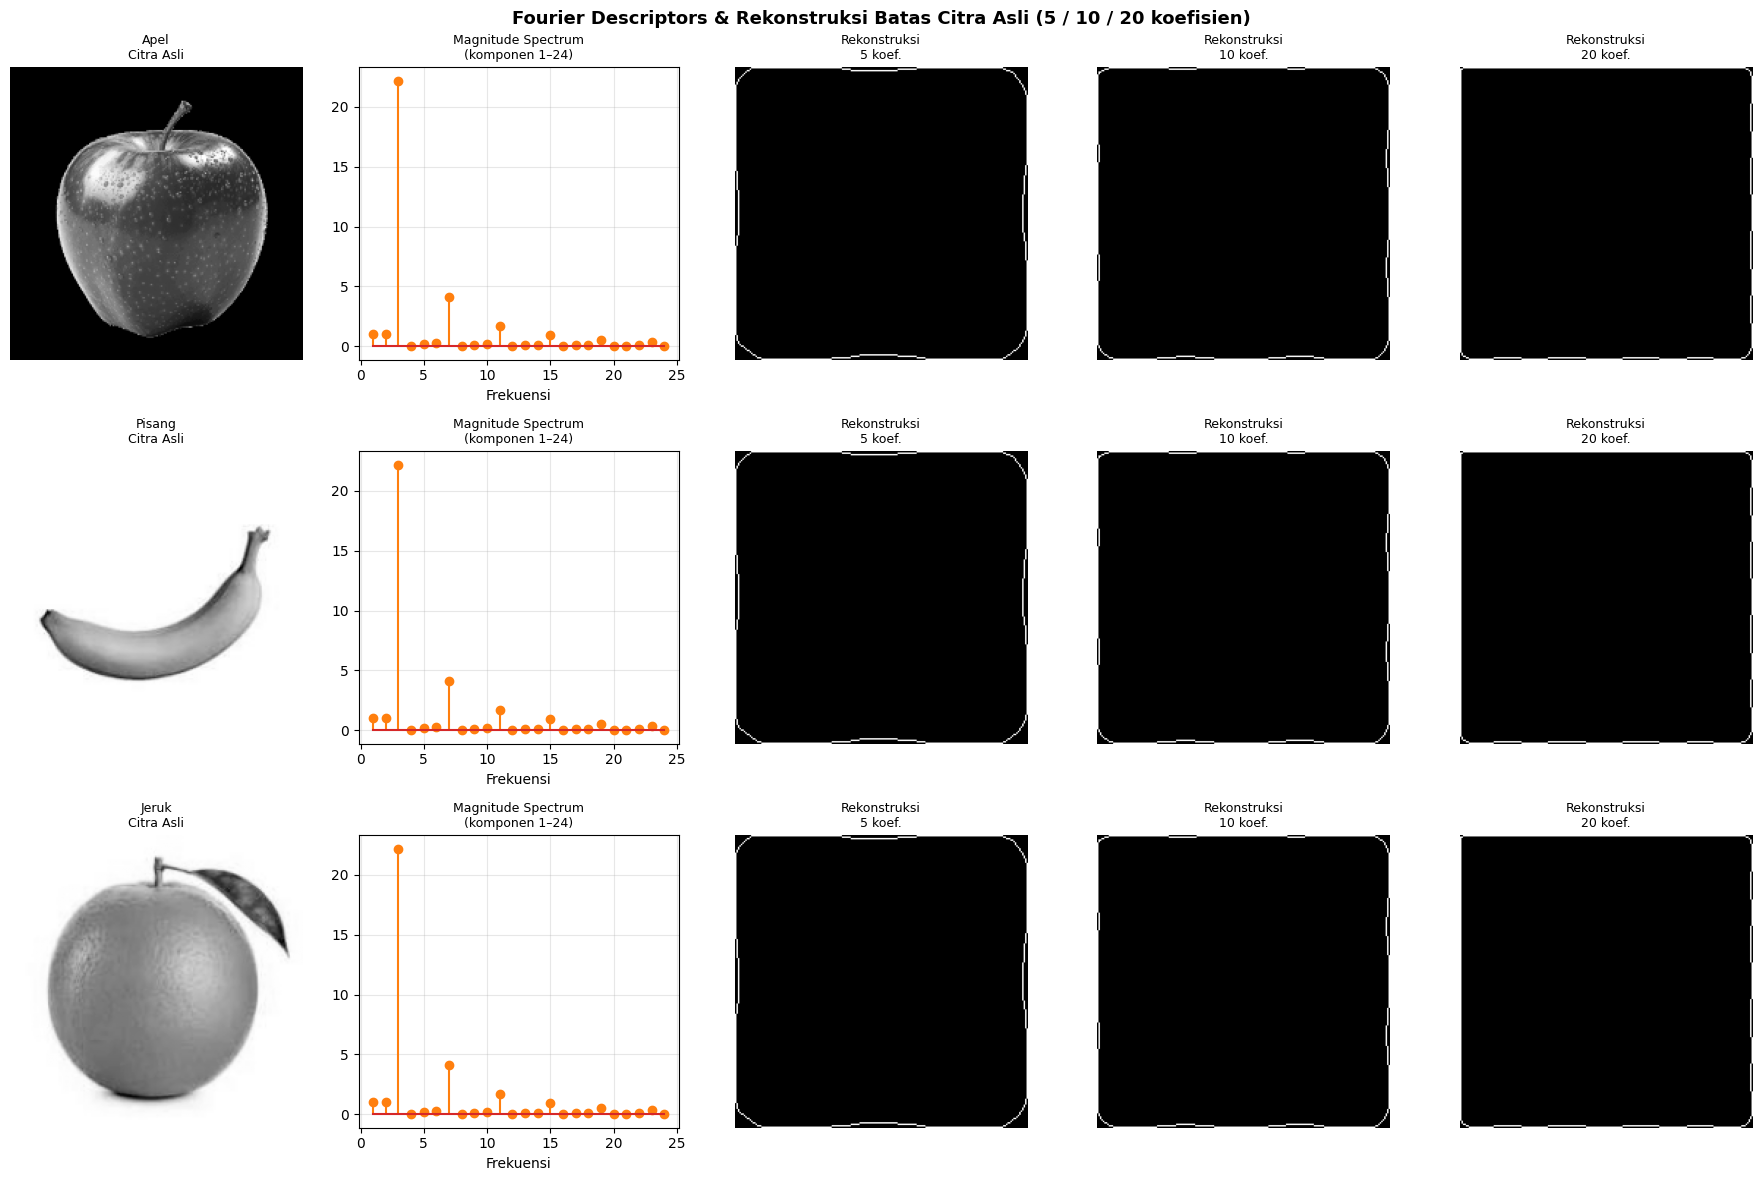


SHAPE SIMILARITY (Euclidean Distance antar Fourier Descriptors):
Nilai kecil = lebih mirip
--------------------------------------------------
  Apel vs Pisang : 0.0000
  Apel vs Jeruk : 0.0000
  Pisang vs Jeruk : 0.0000


In [7]:
# ============================================================
# BAGIAN 5 - FOURIER DESCRIPTORS
# Representasi batas ke domain frekuensi
# Rekonstruksi dengan 5, 10, 20 descriptor
# Normalisasi untuk invariance
# ============================================================

def compute_fourier_descriptors(img, n_samples=128):
    """Hitung Fourier descriptors dari batas kontur."""
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, None, None
    contour = max(contours, key=cv2.contourArea)

    pts = contour[:, 0, :]
    idx = np.linspace(0, len(pts)-1, n_samples).astype(int)
    pts = pts[idx].astype(float)

    z  = pts[:,0] + 1j * pts[:,1]
    fd = np.fft.fft(z)

    fd_norm    = fd.copy()
    fd_norm[0] = 0
    if abs(fd_norm[1]) > 0:
        fd_norm = fd_norm / abs(fd_norm[1])

    return fd, fd_norm, pts


def reconstruct_from_fd(fd, n_coeffs):
    """Rekonstruksi bentuk dari n_coeffs Fourier coefficients."""
    fd_recon  = np.zeros_like(fd)
    n         = len(fd)
    fd_recon[:n_coeffs]   = fd[:n_coeffs]
    fd_recon[n-n_coeffs:] = fd[n-n_coeffs:]
    z_recon   = np.fft.ifft(fd_recon)
    return z_recon.real, z_recon.imag


# Visualisasi Fourier Descriptors dan rekonstruksi
n_coeffs_list = [5, 10, 20]
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle('Fourier Descriptors & Rekonstruksi Batas Citra Asli (5 / 10 / 20 koefisien)', fontsize=13, fontweight='bold')

for cls in range(3):
    img = dataset[cls * 8]
    fd, fd_norm, pts = compute_fourier_descriptors(img)

    # Kolom 0: Original grayscale
    axes[cls,0].imshow(dataset_gray[cls*8], cmap='gray')
    axes[cls,0].set_title(f'{class_names[cls]}\nCitra Asli', fontsize=9)
    axes[cls,0].axis('off')

    # Kolom 1: Magnitude spectrum
    mag = np.abs(fd_norm)
    axes[cls,1].stem(np.arange(1, 25), mag[1:25], markerfmt='C1o', linefmt='C1-')
    axes[cls,1].set_title('Magnitude Spectrum\n(komponen 1–24)', fontsize=9)
    axes[cls,1].set_xlabel('Frekuensi')
    axes[cls,1].grid(True, alpha=0.3)

    # Kolom 2–4: Rekonstruksi
    for col_idx, n_c in enumerate(n_coeffs_list):
        xr, yr = reconstruct_from_fd(fd, n_c)
        recon_img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        pts_recon = np.column_stack([np.clip(xr,0,IMG_SIZE-1).astype(int),
                                     np.clip(yr,0,IMG_SIZE-1).astype(int)])
        for i in range(len(pts_recon)):
            cv2.line(recon_img, tuple(pts_recon[i]),
                     tuple(pts_recon[(i+1)%len(pts_recon)]), 255, 1)
        axes[cls, col_idx+2].imshow(recon_img, cmap='gray')
        axes[cls, col_idx+2].set_title(f'Rekonstruksi\n{n_c} koef.', fontsize=9)
        axes[cls, col_idx+2].axis('off')

plt.tight_layout()
plt.show()

# Uji shape similarity
print('\nSHAPE SIMILARITY (Euclidean Distance antar Fourier Descriptors):')
print('Nilai kecil = lebih mirip')
print('-' * 50)

fd_features = []
for cls in range(3):
    fd, fd_norm, _ = compute_fourier_descriptors(dataset[cls * 8])
    fd_features.append(np.abs(fd_norm[1:21]))

for i in range(3):
    for j in range(i+1, 3):
        dist = np.linalg.norm(fd_features[i] - fd_features[j])
        print(f'  {class_names[i]} vs {class_names[j]} : {dist:.4f}')

## BAGIAN 6 — Ekstraksi Fitur, Klasifikasi k-NN & Evaluasi

EVALUASI K-NN CLASSIFIER (Leave-One-Out Cross Validation, k=3)
  Region Properties              |   5 fitur | Akurasi: 33.3%
  Hu Moments                     |   7 fitur | Akurasi: 16.7%
  Fourier Descriptors            |  20 fitur | Akurasi: 16.7%
  Chain Code Histogram           |   8 fitur | Akurasi: 16.7%
  Region + Hu                    |  12 fitur | Akurasi: 16.7%
  Region + Fourier               |  25 fitur | Akurasi: 16.7%
  Hu + Fourier                   |  27 fitur | Akurasi: 16.7%
  Region + Hu + Fourier          |  32 fitur | Akurasi: 16.7%
  All Features                   |  40 fitur | Akurasi: 16.7%

CLASSIFICATION REPORT — Kombinasi Terbaik: Region Properties
              precision    recall  f1-score   support

        Apel       0.40      1.00      0.57         2
      Pisang       0.33      0.33      0.33         3
       Jeruk       0.00      0.00      0.00         3

    accuracy                           0.38         8
   macro avg       0.24      0.44      0.30  

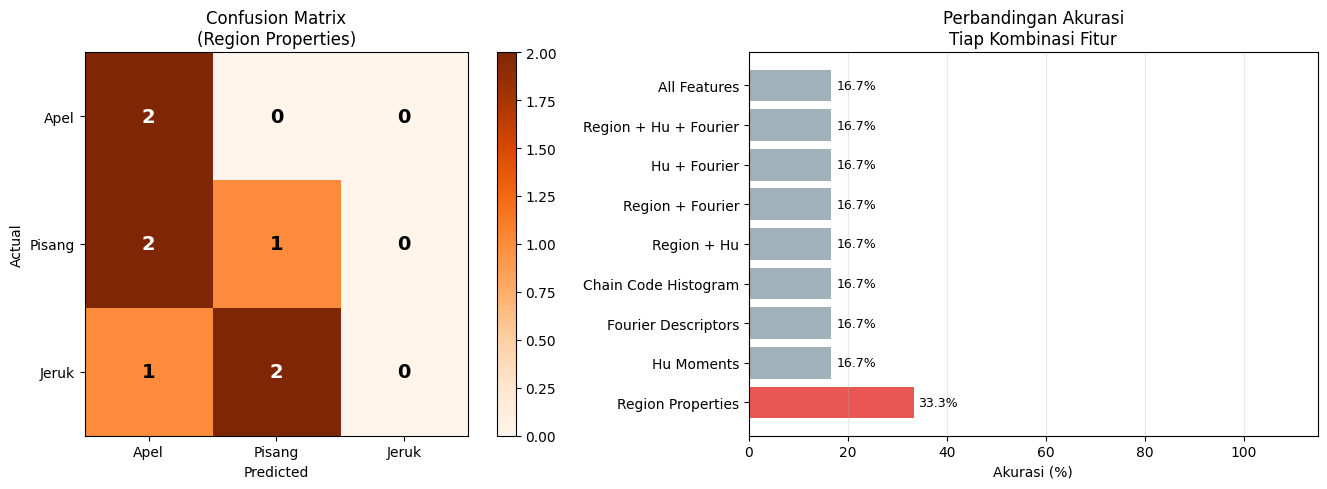


RANKING KOMBINASI FITUR:
          Feature Set  n_features  Accuracy (%)
    Region Properties           5          33.3
           Hu Moments           7          16.7
  Fourier Descriptors          20          16.7
 Chain Code Histogram           8          16.7
          Region + Hu          12          16.7
     Region + Fourier          25          16.7
         Hu + Fourier          27          16.7
Region + Hu + Fourier          32          16.7
         All Features          40          16.7


In [8]:
# ============================================================
# BAGIAN 6 - KLASIFIKASI DAN EVALUASI
# k-NN classifier, akurasi tiap kombinasi fitur
# ============================================================

def extract_all_features(img):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)
    M       = cv2.moments(contour)
    hu      = cv2.HuMoments(M).flatten()
    hu_log  = np.array([-np.sign(h)*np.log10(abs(h)+1e-10) for h in hu])

    area      = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    hull      = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    x,y,w,h  = cv2.boundingRect(contour)

    aspect_ratio  = float(w)/h if h > 0 else 0
    extent        = area/(w*h) if w*h > 0 else 0
    solidity      = area/hull_area if hull_area > 0 else 0
    compactness   = (perimeter**2)/(4*np.pi*area) if area > 0 else 0
    equi_diameter = np.sqrt(4*area/np.pi)

    fd, fd_norm, _ = compute_fourier_descriptors(img)
    fd_feat = np.abs(fd_norm[1:21]) if fd_norm is not None else np.zeros(20)

    chain, _, _ = compute_chain_code(contour, mode=8)
    chain_hist  = np.zeros(8)
    for c in chain:
        chain_hist[c] += 1
    if len(chain) > 0:
        chain_hist /= len(chain)

    return {
        'region':  np.array([aspect_ratio, extent, solidity,
                             compactness, equi_diameter/IMG_SIZE]),
        'hu':      hu_log[:7],
        'fourier': fd_feat,
        'chain':   chain_hist
    }

all_features = [extract_all_features(img) for img in dataset]

X_region  = np.array([f['region']  for f in all_features])
X_hu      = np.array([f['hu']      for f in all_features])
X_fourier = np.array([f['fourier'] for f in all_features])
X_chain   = np.array([f['chain']   for f in all_features])
X_all     = np.hstack([X_region, X_hu, X_fourier, X_chain])
y         = np.array(labels)

feature_sets = {
    'Region Properties':     X_region,
    'Hu Moments':            X_hu,
    'Fourier Descriptors':   X_fourier,
    'Chain Code Histogram':  X_chain,
    'Region + Hu':           np.hstack([X_region, X_hu]),
    'Region + Fourier':      np.hstack([X_region, X_fourier]),
    'Hu + Fourier':          np.hstack([X_hu, X_fourier]),
    'Region + Hu + Fourier': np.hstack([X_region, X_hu, X_fourier]),
    'All Features':          X_all
}

print('EVALUASI K-NN CLASSIFIER (Leave-One-Out Cross Validation, k=3)')
print('=' * 65)

results = []
scaler  = StandardScaler()

for name, X in feature_sets.items():
    X_scaled = scaler.fit_transform(X)
    knn      = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
    loo      = LeaveOneOut()
    scores   = cross_val_score(knn, X_scaled, y, cv=loo)
    acc      = scores.mean() * 100
    results.append({'Feature Set': name, 'n_features': X.shape[1], 'Accuracy (%)': round(acc, 1)})
    print(f'  {name:<30} | {X.shape[1]:>3} fitur | Akurasi: {acc:.1f}%')

df_results = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False)

# Confusion Matrix untuk kombinasi terbaik
best_name = df_results.iloc[0]['Feature Set']
X_best    = feature_sets[best_name]
X_best_sc = scaler.fit_transform(X_best)

X_tr, X_te, y_tr, y_te = train_test_split(X_best_sc, y, test_size=0.33, random_state=42, stratify=y)
knn_best = KNeighborsClassifier(n_neighbors=3)
knn_best.fit(X_tr, y_tr)
y_pred = knn_best.predict(X_te)

print(f'\nCLASSIFICATION REPORT — Kombinasi Terbaik: {best_name}')
print(classification_report(y_te, y_pred, target_names=class_names))

cm = confusion_matrix(y_te, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(cm, cmap='Oranges')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(class_names); axes[0].set_yticklabels(class_names)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix\n({best_name})')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[0])

names      = [r['Feature Set'] for r in results]
accs       = [r['Accuracy (%)'] for r in results]
colors_bar = ['#E53935' if a == max(accs) else '#90A4AE' for a in accs]
axes[1].barh(names, accs, color=colors_bar, alpha=0.85)
axes[1].set_xlabel('Akurasi (%)')
axes[1].set_title('Perbandingan Akurasi\nTiap Kombinasi Fitur')
axes[1].set_xlim(0, 115)
for i, a in enumerate(accs):
    axes[1].text(a+1, i, f'{a:.1f}%', va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nRANKING KOMBINASI FITUR:')
print(df_results.to_string(index=False))

## BAGIAN 7 — Identifikasi Fitur Paling Diskriminatif

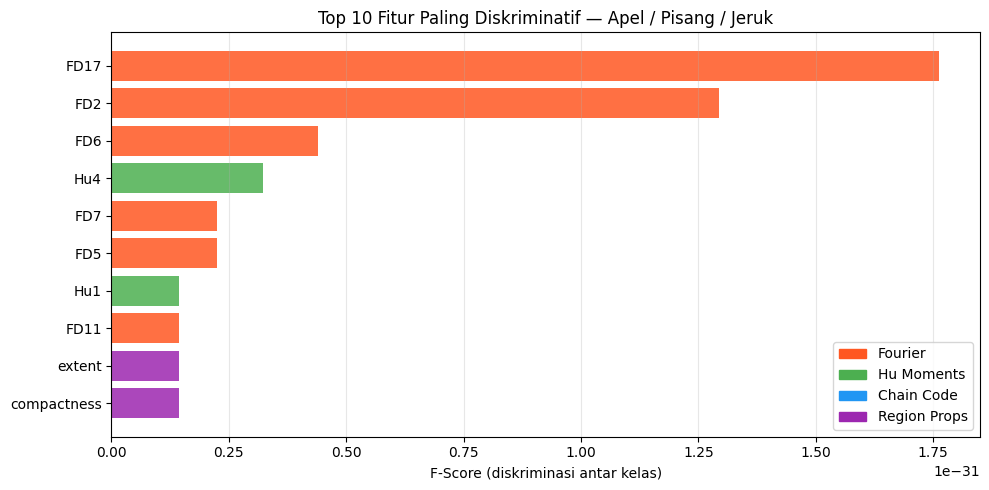

TOP 10 FITUR PALING DISKRIMINATIF:
Rank   Fitur                   F-Score Kategori            
------------------------------------------------------------
1      FD17                      0.000 Fourier             
2      FD2                       0.000 Fourier             
3      FD6                       0.000 Fourier             
4      Hu4                       0.000 Hu Moments          
5      FD7                       0.000 Fourier             
6      FD5                       0.000 Fourier             
7      Hu1                       0.000 Hu Moments          
8      FD11                      0.000 Fourier             
9      extent                    0.000 Region Props        
10     compactness               0.000 Region Props        

KESIMPULAN:
Fitur dengan F-Score tertinggi adalah yang paling mampu
membedakan Apel, Pisang, dan Jeruk berdasarkan bentuk konturnya.


In [9]:
# ============================================================
# BAGIAN 7 - IDENTIFIKASI FITUR PALING DISKRIMINATIF
# Menggunakan F-score (between-class / within-class variance)
# ============================================================

feature_names = (
    ['aspect_ratio','extent','solidity','compactness','equi_diameter'] +
    [f'Hu{i+1}'  for i in range(7)] +
    [f'FD{i+1}'  for i in range(20)] +
    [f'CC{i}'    for i in range(8)]
)

X_all_scaled = StandardScaler().fit_transform(X_all)

f_scores = []
for feat_idx in range(X_all_scaled.shape[1]):
    feat         = X_all_scaled[:, feat_idx]
    overall_mean = feat.mean()
    between = sum(N_SAMPLES * (feat[y==c].mean() - overall_mean)**2 for c in range(3)) / 2
    within  = sum(((feat[y==c] - feat[y==c].mean())**2).sum() for c in range(3)) / (len(y)-3)
    f_scores.append(between / (within + 1e-10))

top_idx   = np.argsort(f_scores)[::-1][:10]
top_names = [feature_names[i] for i in top_idx]
top_score = [f_scores[i]      for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 5))
colors_f = ['#FF5722' if n.startswith('FD') else
            '#4CAF50' if n.startswith('Hu') else
            '#2196F3' if n.startswith('CC') else '#9C27B0'
            for n in top_names]
ax.barh(top_names[::-1], top_score[::-1], color=colors_f[::-1], alpha=0.85)
ax.set_xlabel('F-Score (diskriminasi antar kelas)')
ax.set_title('Top 10 Fitur Paling Diskriminatif — Apel / Pisang / Jeruk')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(color='#FF5722', label='Fourier'),
    Patch(color='#4CAF50', label='Hu Moments'),
    Patch(color='#2196F3', label='Chain Code'),
    Patch(color='#9C27B0', label='Region Props')
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print('TOP 10 FITUR PALING DISKRIMINATIF:')
print(f"{'Rank':<6} {'Fitur':<20} {'F-Score':>10} {'Kategori':<20}")
print('-' * 60)
for rank, (name, score) in enumerate(zip(top_names, top_score), 1):
    cat = ('Fourier'      if name.startswith('FD') else
           'Hu Moments'   if name.startswith('Hu') else
           'Chain Code'   if name.startswith('CC') else 'Region Props')
    print(f"{rank:<6} {name:<20} {score:>10.3f} {cat:<20}")

print('\nKESIMPULAN:')
print('Fitur dengan F-Score tertinggi adalah yang paling mampu')
print('membedakan Apel, Pisang, dan Jeruk berdasarkan bentuk konturnya.')